Задача классификации цветов автомобилей.


Дообучить два классификатора цветов машин на наборе данных DVM, взяв модели, предобученные на ImageNet и на чем-то другом.

In [8]:
import torch

device = torch.device("cuda")
torch.manual_seed(52)
torch.cuda.manual_seed(52)
torch.backends.cudnn.benchmark = True

Датасет для парсинга цвета из имени файла

In [9]:
import os
from torch.utils.data import Dataset

class CarColorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.color_to_idx = {}
        self.idx_to_color = {}

        for brand in os.listdir(root_dir):
            brand_path = os.path.join(root_dir, brand)
            if not os.path.isdir(brand_path):
                continue

            for year in os.listdir(brand_path):
                year_path = os.path.join(brand_path, year)
                if not os.path.isdir(year_path):
                    continue

                for img_name in os.listdir(year_path):
                    parts = img_name.split('$$')
                    if len(parts) >= 4:
                        color = parts[3]
                        img_path = os.path.join(year_path, img_name)

                        self.image_paths.append(img_path)
                        self.labels.append(color)

                        # Маппим цвет к цислу
                        if color not in self.color_to_idx:
                            idx = len(self.color_to_idx)
                            self.color_to_idx[color] = idx
                            self.idx_to_color[idx] = color

        # Маппим цвет к цислу
        self.labels_idx = [self.color_to_idx[label] for label in self.labels]

        print(f"Найдено изображений: {len(self.image_paths)}")
        print(f"Классы (цвета): {list(self.color_to_idx.keys())}")
        print(f"Количество классов: {len(self.color_to_idx)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels_idx[idx]

        # Загрузка изображения (PIL)
        from PIL import Image
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

    def get_num_classes(self):
        return len(self.color_to_idx)

    def get_class_names(self):
        return list(self.color_to_idx.keys())

Создаем датасет и сплитим на выборки

In [10]:
from torch.utils.data import random_split, DataLoader
from torchvision import transforms

data_root = './confirmed_fronts'

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = CarColorDataset(root_dir=data_root, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset.transform = val_transform

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

class_names = full_dataset.get_class_names()
num_classes = full_dataset.get_num_classes()

Найдено изображений: 61827
Классы (цвета): ['Black', 'Grey', 'Multicolour', 'White', 'Red', 'Blue', 'Unlisted', 'Yellow', 'Silver', 'Turquoise', 'Bronze', 'Green', 'Beige', 'Purple', 'Brown', 'Orange', 'Pink', 'Maroon', 'Navy', 'Gold', 'Burgundy', 'Magenta', 'Indigo']
Количество классов: 23


Модель, предобученная с ImageNet

In [11]:
from torchvision import models
import torch.nn as nn

weights = models.ResNet18_Weights.IMAGENET1K_V1
model_imagenet = models.resnet18(weights=weights)

for param in model_imagenet.parameters():
    param.requires_grad = True

num_features = model_imagenet.fc.in_features
model_imagenet.fc = nn.Linear(num_features, num_classes)

Модель, предобученная с SWSL (Instagram IG-1B)

In [12]:
import timm

model_swsl = timm.create_model('swsl_resnet18', pretrained=True)

for param in model_swsl.parameters():
    param.requires_grad = True

num_features_swsl = model_swsl.fc.in_features
model_swsl.fc = nn.Linear(num_features_swsl, num_classes)

Функция обучения

In [13]:
import copy
from torch.amp import autocast, GradScaler
from sklearn.metrics import f1_score

def train_model(model, criterion, optimizer, scheduler, num_epochs):
    model = model.to(device)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}

    scaler = GradScaler()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_corrects = 0
            total = 0
            all_preds = []
            all_labels = []

            for inputs, labels in loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast(device_type='cuda'):
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_corrects += torch.sum(preds == labels.data)
                total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if phase == 'train':
                scheduler.step()

            epoch_acc = running_corrects.double() / total
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')
            print(f'{phase} Acc: {epoch_acc:.4f} | F1_macro: {epoch_f1:.4f}')

            if phase == 'val':
                history['val_acc'].append(epoch_acc.item())
                history['val_f1'].append(epoch_f1)
            else:
                history['train_acc'].append(epoch_acc.item())
                history['train_f1'].append(epoch_f1)

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    print(f'Best val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

Модель ImageNet

In [14]:
from torch import optim

num_epochs = 10
criterion = nn.CrossEntropyLoss()

optimizer_imagenet = optim.SGD(model_imagenet.parameters(), lr=0.001, momentum=0.9)
scheduler_imagenet = optim.lr_scheduler.StepLR(optimizer_imagenet, step_size=7, gamma=0.1)

model_imagenet, hist_imagenet = train_model(
    model_imagenet, criterion, optimizer_imagenet, scheduler_imagenet, num_epochs
)

Epoch 0/9
----------
train Acc: 0.7118 | F1_macro: 0.2530
val Acc: 0.8065 | F1_macro: 0.3775

Epoch 1/9
----------
train Acc: 0.8296 | F1_macro: 0.3587
val Acc: 0.8372 | F1_macro: 0.4228

Epoch 2/9
----------
train Acc: 0.8581 | F1_macro: 0.3955
val Acc: 0.8467 | F1_macro: 0.4415

Epoch 3/9
----------
train Acc: 0.8790 | F1_macro: 0.4278
val Acc: 0.8583 | F1_macro: 0.4608

Epoch 4/9
----------
train Acc: 0.8947 | F1_macro: 0.4487
val Acc: 0.8572 | F1_macro: 0.4723

Epoch 5/9
----------
train Acc: 0.9090 | F1_macro: 0.4825
val Acc: 0.8649 | F1_macro: 0.5016

Epoch 6/9
----------
train Acc: 0.9246 | F1_macro: 0.5118
val Acc: 0.8683 | F1_macro: 0.5185

Epoch 7/9
----------
train Acc: 0.9419 | F1_macro: 0.5378
val Acc: 0.8700 | F1_macro: 0.5238

Epoch 8/9
----------
train Acc: 0.9434 | F1_macro: 0.5410
val Acc: 0.8679 | F1_macro: 0.5243

Epoch 9/9
----------
train Acc: 0.9457 | F1_macro: 0.5551
val Acc: 0.8705 | F1_macro: 0.5275

Best val Acc: 0.8705


Модель SWSL

In [15]:
optimizer_swsl = optim.SGD(model_swsl.parameters(), lr=0.001, momentum=0.9)
scheduler_swsl = optim.lr_scheduler.StepLR(optimizer_swsl, step_size=7, gamma=0.1)

model_swsl, hist_swsl = train_model(
    model_swsl, criterion, optimizer_swsl, scheduler_swsl, num_epochs
)

Epoch 0/9
----------
train Acc: 0.7725 | F1_macro: 0.3287
val Acc: 0.8380 | F1_macro: 0.4389

Epoch 1/9
----------
train Acc: 0.8702 | F1_macro: 0.4471
val Acc: 0.8576 | F1_macro: 0.5062

Epoch 2/9
----------
train Acc: 0.9059 | F1_macro: 0.5149
val Acc: 0.8729 | F1_macro: 0.5440

Epoch 3/9
----------
train Acc: 0.9328 | F1_macro: 0.5855
val Acc: 0.8484 | F1_macro: 0.5221

Epoch 4/9
----------
train Acc: 0.9568 | F1_macro: 0.6551
val Acc: 0.8605 | F1_macro: 0.5492

Epoch 5/9
----------
train Acc: 0.9782 | F1_macro: 0.7184
val Acc: 0.8732 | F1_macro: 0.5572

Epoch 6/9
----------
train Acc: 0.9905 | F1_macro: 0.7800
val Acc: 0.8750 | F1_macro: 0.5664

Epoch 7/9
----------
train Acc: 0.9964 | F1_macro: 0.8121
val Acc: 0.8811 | F1_macro: 0.5753

Epoch 8/9
----------
train Acc: 0.9970 | F1_macro: 0.8112
val Acc: 0.8816 | F1_macro: 0.5751

Epoch 9/9
----------
train Acc: 0.9972 | F1_macro: 0.8178
val Acc: 0.8823 | F1_macro: 0.5745

Best val Acc: 0.8823


Сравнение двух моделей

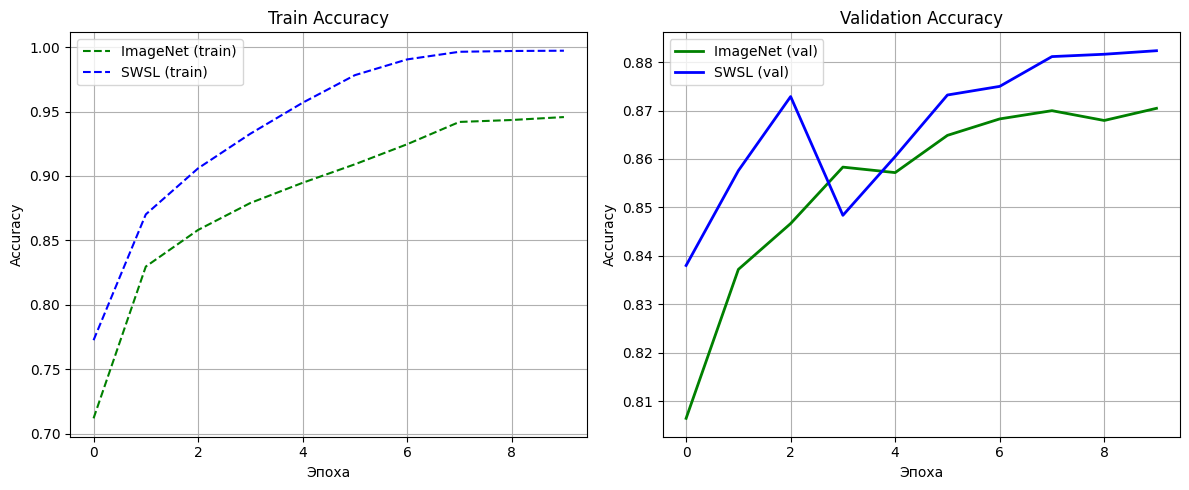

In [18]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_imagenet['train_acc'], label='ImageNet (train)', color='green', linestyle='--')
plt.plot(hist_swsl['train_acc'], label='SWSL (train)', color='blue', linestyle='--')
plt.title('Train Accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_imagenet['val_acc'], label='ImageNet (val)', color='green', linewidth=2)
plt.plot(hist_swsl['val_acc'], label='SWSL (val)', color='blue', linewidth=2)
plt.title('Validation Accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Обучить с нуля собственный классификатор (и обосновать выбор архитектуры)


Архитектура: цвет автомобиля это достаточно низкоуровнеый признак для которого не требуется множество слоев, поэтому была сделана архитектура: 4 свёрточных блока (Conv + BatchNorm + ReLU + MaxPool) + классификатор с Dropout

In [19]:
class CarColorCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = CarColorCNN(num_classes)

Обучение собственного классификатор

In [20]:
optimizer_scratch = optim.SGD(model_scratch.parameters(), lr=0.01, momentum=0.9)
scheduler_scratch = optim.lr_scheduler.StepLR(optimizer_scratch, step_size=7, gamma=0.1)

model_scratch, hist_scratch = train_model(
    model_scratch, criterion, optimizer_scratch, scheduler_scratch, num_epochs
)

Epoch 0/9
----------
train Acc: 0.5201 | F1_macro: 0.1627
val Acc: 0.5082 | F1_macro: 0.2035

Epoch 1/9
----------
train Acc: 0.6133 | F1_macro: 0.2117
val Acc: 0.5404 | F1_macro: 0.2297

Epoch 2/9
----------
train Acc: 0.6454 | F1_macro: 0.2356
val Acc: 0.5330 | F1_macro: 0.2452

Epoch 3/9
----------
train Acc: 0.6720 | F1_macro: 0.2556
val Acc: 0.6735 | F1_macro: 0.3118

Epoch 4/9
----------
train Acc: 0.6909 | F1_macro: 0.2642
val Acc: 0.7142 | F1_macro: 0.3092

Epoch 5/9
----------
train Acc: 0.6990 | F1_macro: 0.2714
val Acc: 0.7058 | F1_macro: 0.3149

Epoch 6/9
----------
train Acc: 0.7125 | F1_macro: 0.2833
val Acc: 0.6386 | F1_macro: 0.3020

Epoch 7/9
----------
train Acc: 0.7398 | F1_macro: 0.2983
val Acc: 0.7639 | F1_macro: 0.3530

Epoch 8/9
----------
train Acc: 0.7446 | F1_macro: 0.3029
val Acc: 0.7656 | F1_macro: 0.3583

Epoch 9/9
----------
train Acc: 0.7468 | F1_macro: 0.3031
val Acc: 0.7642 | F1_macro: 0.3618

Best val Acc: 0.7656


Оценить качество при помощи F1_macro. Какой вывод можно сделать из значения метрики?


F1 vacro у модели сильно ниже accuracy, значит классы сильно несбалансированы. Accuracy высокая потому что модель хорошо угадывает частые цвета, но редкие цвета модель почти не различает (слишком мало данных с ними для обучения). (вообще надо было датасет на 13 гигов качать, но я бы не дождался бы конца обучения никогда)

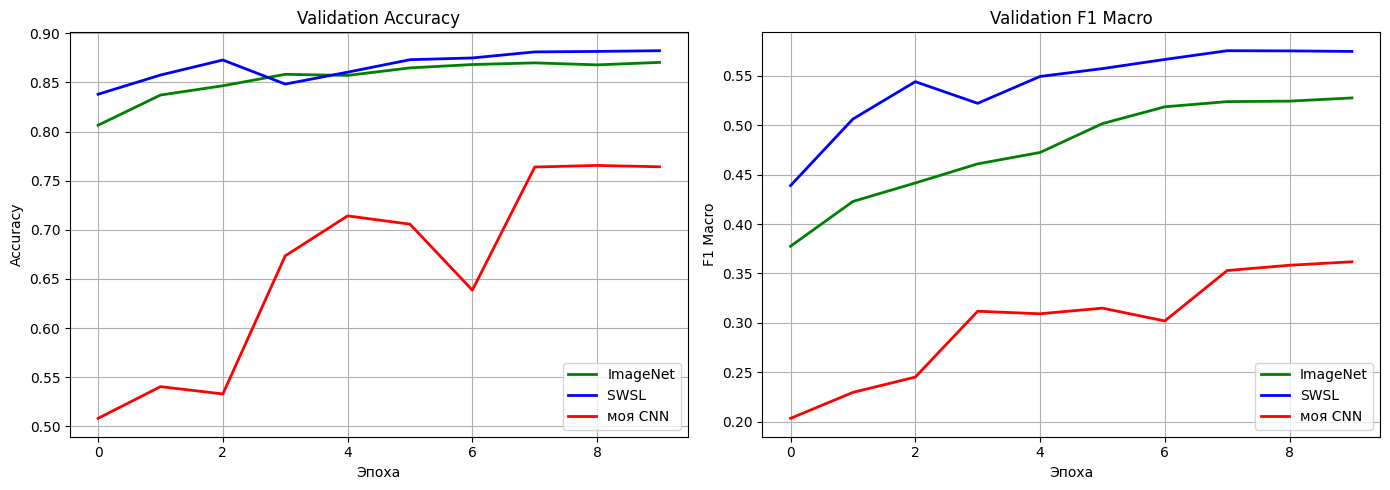

In [22]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_imagenet['val_acc'], label='ImageNet', color='green', linewidth=2)
axes[0].plot(hist_swsl['val_acc'], label='SWSL ', color='blue', linewidth=2)
axes[0].plot(hist_scratch['val_acc'], label='моя CNN', color='red', linewidth=2)
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist_imagenet['val_f1'], label='ImageNet', color='green', linewidth=2)
axes[1].plot(hist_swsl['val_f1'], label='SWSL', color='blue', linewidth=2)
axes[1].plot(hist_scratch['val_f1'], label='моя CNN', color='red', linewidth=2)
axes[1].set_title('Validation F1 Macro')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('F1 Macro')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Сравнить полученное качество и сделать вывод


У всех моделей f1 macro у всех моделей значительно ниже accuracy из-за сильного дизбаланса классов в датасете.

В таких ситуациях, когда ограничен объем данных transfer learning крайне необходим, тк дает большой буст к метрикам.